In [2]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import calendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

In [3]:
data = pd.read_csv('example_wp_log_peyton_manning.csv')

In [4]:
data.head()

,ds,y
0,10-12-2007,9.590761
1,11-12-2007,8.519590
2,12-12-2007,8.183677
3,13-12-2007,8.072467
4,14-12-2007,7.893572


In [5]:
data['ds'] = pd.to_datetime(data['ds'], format = '%d-%m-%Y')

In [6]:
data.head()

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2905 entries, 0 to 2904
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      2905 non-null   datetime64[ns]
 1   y       2905 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 45.5 KB


<Axes: >

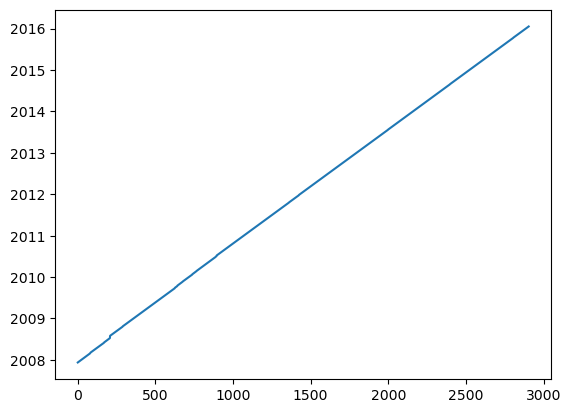

In [8]:
data['ds'].plot()

In [9]:
model = Prophet()
model.fit(data)

19:42:25 - cmdstanpy - INFO - Chain [1] start processing
19:42:25 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
model.component_modes

{'additive': ['yearly',
  'weekly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [11]:
data.tail()

,ds,y
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871
2904,2016-01-20,8.891374


In [12]:
future = model.make_future_dataframe(periods=365)
future.tail()

,ds
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18
3269,2017-01-19


In [13]:
prediction = model.predict(future)
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2007-12-10,8.042860,8.192030,9.446587,8.042860,8.042860,0.803214,0.803214,0.803214,0.352297,0.352297,0.352297,0.450917,0.450917,0.450917,0.0,0.0,0.0,8.846075
1,2007-12-11,8.041307,7.957320,9.219586,8.041307,8.041307,0.553276,0.553276,0.553276,0.119648,0.119648,0.119648,0.433628,0.433628,0.433628,0.0,0.0,0.0,8.594583
2,2007-12-12,8.039755,7.772505,9.022083,8.039755,8.039755,0.350618,0.350618,0.350618,-0.066655,-0.066655,-0.066655,0.417273,0.417273,0.417273,0.0,0.0,0.0,8.390373
3,2007-12-13,8.038202,7.732851,8.997901,8.038202,8.038202,0.330041,0.330041,0.330041,-0.072257,-0.072257,-0.072257,0.402298,0.402298,0.402298,0.0,0.0,0.0,8.368244
4,2007-12-14,8.036650,7.719689,8.980020,8.036650,8.036650,0.319536,0.319536,0.319536,-0.069573,-0.069573,-0.069573,0.389109,0.389109,0.389109,0.0,0.0,0.0,8.356186


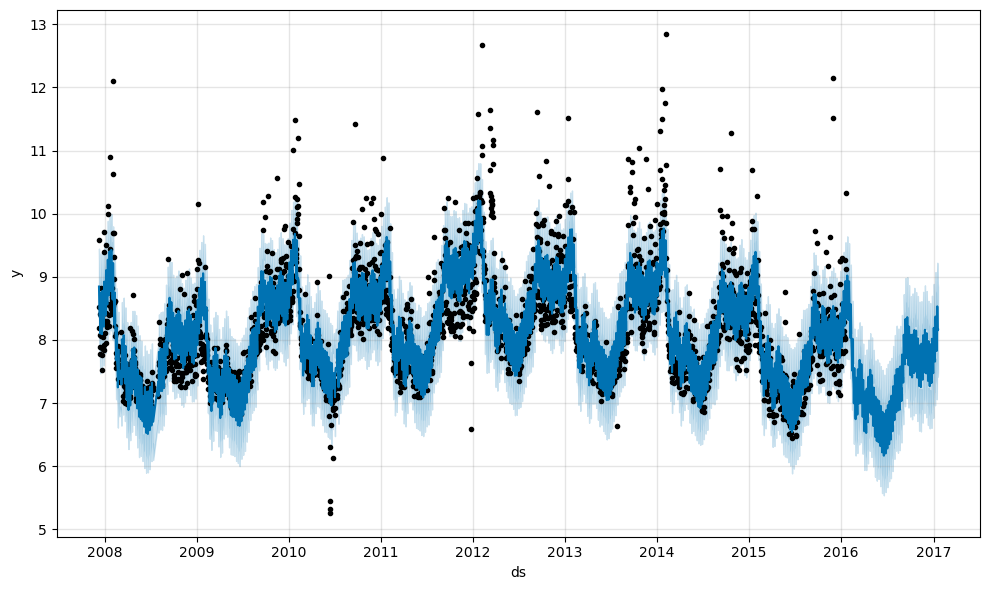

In [14]:
model.plot(prediction)
plt.savefig('prediction.png', bbox_inches='tight')
plt.show();

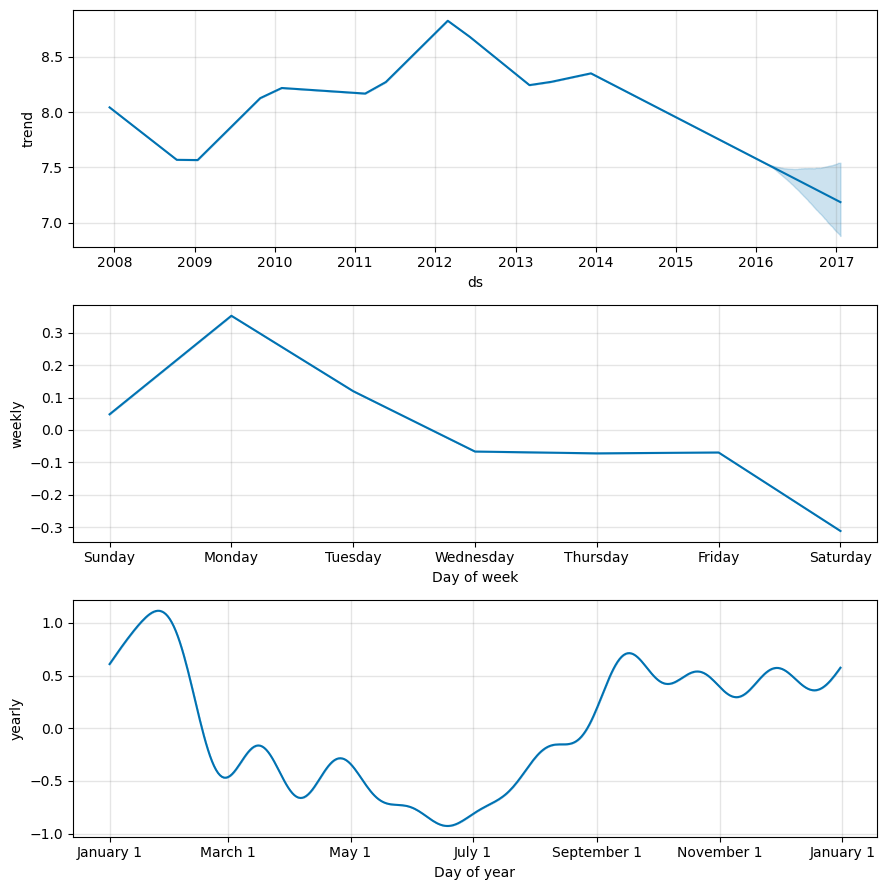

In [21]:
model.plot_components(prediction)
plt.savefig('trend_decomposition.png', bbox_inches='tight')
plt.show();

In [16]:
data.shape

(2905, 2)

In [17]:
data.tail()

,ds,y
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871
2904,2016-01-20,8.891374


In [18]:
# initial ='730 days' : first 2 years used for training
# period = '180 days' : after every 180 days the model creates a new cutoff, retraining from start to that cutoff point
# horizon = '365 days' : at each cutoff point the model forecasts 1 year ahead and compares with the actual values
data_cv = cross_validation(model, initial = '730 days', period = '180 days', horizon = '365 days')
data_cv.head()

  0%|          | 0/11 [00:00<?, ?it/s]

19:42:27 - cmdstanpy - INFO - Chain [1] start processing
19:42:27 - cmdstanpy - INFO - Chain [1] done processing
19:42:28 - cmdstanpy - INFO - Chain [1] start processing
19:42:28 - cmdstanpy - INFO - Chain [1] done processing
19:42:28 - cmdstanpy - INFO - Chain [1] start processing
19:42:28 - cmdstanpy - INFO - Chain [1] done processing
19:42:28 - cmdstanpy - INFO - Chain [1] start processing
19:42:29 - cmdstanpy - INFO - Chain [1] done processing
19:42:29 - cmdstanpy - INFO - Chain [1] start processing
19:42:29 - cmdstanpy - INFO - Chain [1] done processing
19:42:29 - cmdstanpy - INFO - Chain [1] start processing
19:42:30 - cmdstanpy - INFO - Chain [1] done processing
19:42:30 - cmdstanpy - INFO - Chain [1] start processing
19:42:30 - cmdstanpy - INFO - Chain [1] done processing
19:42:30 - cmdstanpy - INFO - Chain [1] start processing
19:42:31 - cmdstanpy - INFO - Chain [1] done processing
19:42:31 - cmdstanpy - INFO - Chain [1] start processing
19:42:31 - cmdstanpy - INFO - Chain [1]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2010-02-16,8.958833,8.434900,9.454689,8.242493,2010-02-15
1,2010-02-17,8.725314,8.204984,9.237410,8.008033,2010-02-15
2,2010-02-18,8.609108,8.137209,9.122682,8.045268,2010-02-15
3,2010-02-19,8.531027,8.018237,9.040196,7.928766,2010-02-15
4,2010-02-20,8.273056,7.752926,8.790411,7.745003,2010-02-15


In [19]:
data_p = performance_metrics(data_cv)
data_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days,0.495625,0.704006,0.505842,0.058610,0.049970,0.058912,0.681590
1,38 days,0.501446,0.708129,0.510822,0.059186,0.049755,0.059548,0.681590
2,39 days,0.523732,0.723693,0.516918,0.059785,0.049896,0.060274,0.680219
3,40 days,0.531017,0.728709,0.519787,0.060092,0.049479,0.060650,0.683874
4,41 days,0.538485,0.733815,0.520742,0.060166,0.049755,0.060789,0.691412


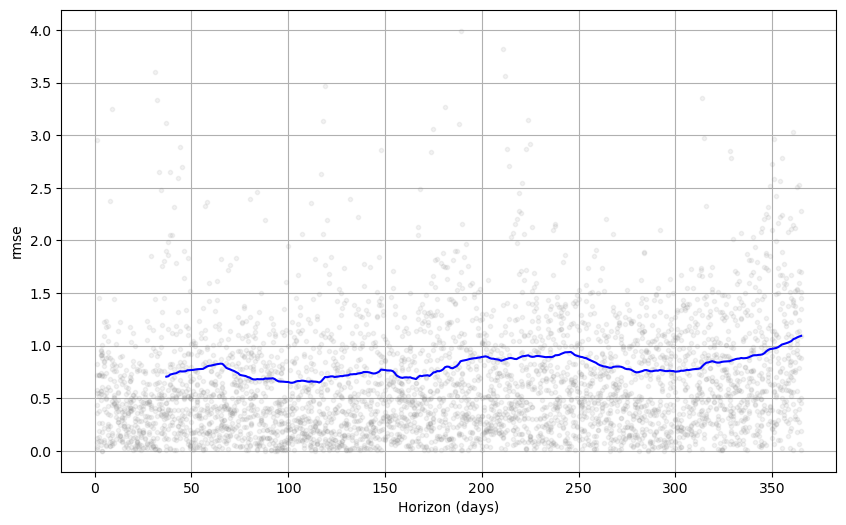

In [20]:
fig = plot_cross_validation_metric(data_cv, metric='rmse')
plt.savefig('rmse_plot.png', bbox_inches='tight')
p